<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_Team6_Project_M2_Xiaoxuan_Zhu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA for Research Question 1: Movement Behavior Profiles Among Cats

This notebook supports Milestone 2 and focuses on the first research question from the project proposal:
whether distinct outdoor movement behavior profiles can be identified among cats in terms of
movement intensity, temporal activity patterns, and spatial roaming ranges.

Rather than focusing on isolated extreme events, the goal of this analysis is to examine
cat-level behavioral patterns constructed across multiple movement dimensions. The emphasis
is on identifying systematic differences across individuals that may reflect distinct
movement behavior profiles.

## 1. Data Loading & Cleaning

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cats_uk_reference.csv to cats_uk_reference (1).csv
Saving cats_uk.csv to cats_uk (1).csv


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'cats_uk_reference (1).csv', 'cats_uk (1).csv', 'cats_uk_reference.csv', 'cats_uk.csv', 'sample_data']


In [ ]:
import pandas as pd

events = pd.read_csv("/content/cats_uk.csv")
ref    = pd.read_csv("/content/cats_uk_reference.csv")

print(events.shape)
print(ref.shape)

(18215, 11)
(101, 16)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Events columns:", events.columns.tolist())
print("Ref columns   :", ref.columns.tolist())

Events columns: ['tag_id', 'event_id', 'visible', 'timestamp', 'location_long', 'location_lat', 'ground_speed', 'height_above_ellipsoid', 'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name']
Ref columns   : ['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date', 'deploy_off_date', 'hunt', 'prey_p_month', 'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats', 'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years']


In [ ]:
print("Events columns:")
events.columns.tolist()

Events columns:


['tag_id',
 'event_id',
 'visible',
 'timestamp',
 'location_long',
 'location_lat',
 'ground_speed',
 'height_above_ellipsoid',
 'algorithm_marked_outlier',
 'manually_marked_outlier',
 'study_name']

In [ ]:
COL = {
    "cat_id": "tag_id",
    "timestamp": "timestamp",
    "speed": "ground_speed",
    "lat": "location_lat",
    "lon": "location_long"
}

In [ ]:
df = events.copy()
print(df.shape)
df.head()

(18215, 11)


,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [ ]:
df = df.dropna(subset=[COL["cat_id"], COL["speed"]])

df[COL["speed"]] = pd.to_numeric(df[COL["speed"]], errors="coerce")
df = df.dropna(subset=[COL["speed"]])

df = df[df[COL["speed"]] >= 0]

print("After minimal cleaning:", df.shape)

After minimal cleaning: (18215, 11)


## 2. EDA Step 1: GPS Sampling Imbalance

In [ ]:
obs_count = (
    df.groupby(COL["cat_id"])
      .size()
      .reset_index(name="n_obs")
)

obs_count.describe()


,n_obs
count,101.000000
mean,180.346535
std,146.280582
min,12.000000
25%,100.000000
50%,155.000000
75%,214.000000
max,963.000000


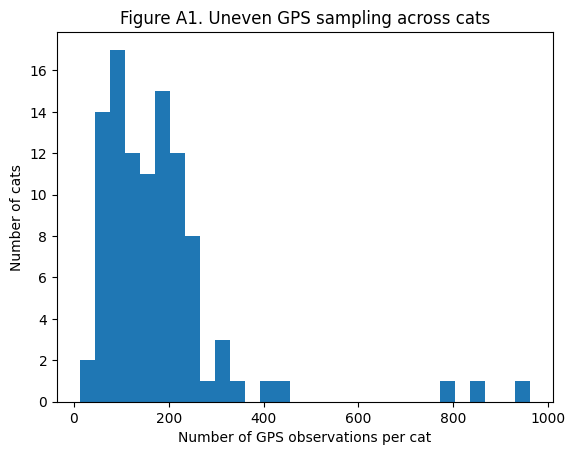

In [69]:
plt.figure()
plt.hist(obs_count["n_obs"], bins=30)
plt.xlabel("Number of GPS observations per cat")
plt.ylabel("Number of cats")
plt.title("Figure A1. Uneven GPS sampling across cats")
plt.show()

Before analyzing movement behavior, I assess GPS sampling coverage across individual cats.
The number of observations varies substantially, indicating that some cats are tracked much
more frequently than others. This imbalance motivates the use of cat-level aggregated features rather than raw GPS points.
By aggregating observations I aim to construct comparable
behavioral summaries that better reflect stable movement profiles across cats.

## 3. EDA Step 2: Distribution of Movement Speed


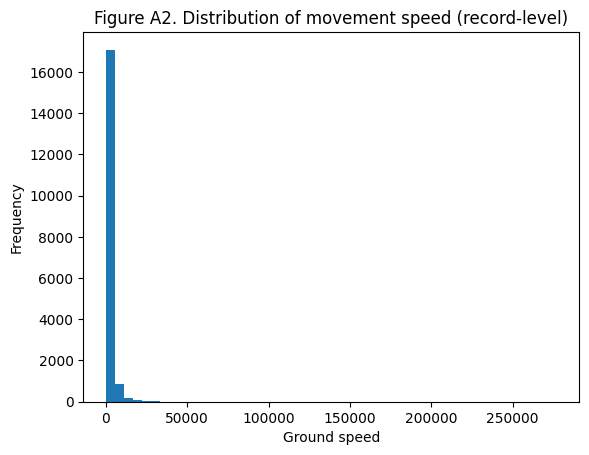

In [70]:
plt.figure()
plt.hist(df[COL["speed"]], bins=50)
plt.xlabel("Ground speed")
plt.ylabel("Frequency")
plt.title("Figure A2. Distribution of movement speed (record-level)")
plt.show()

The distribution of ground speed is highly right-skewed, with most observations occurring
at low speeds and a smaller number of higher-speed movements.
 This distribution suggests that average-based summaries alone may be insufficient to
characterize movement behavior. Instead, multiple complementary measures are needed to
capture heterogeneity in movement intensity across cats.

## 4. EDA Step 3: Distribution of Maximum Speed Across Cats

In [ ]:
cat_max_speed = (
    df.groupby(COL["cat_id"])[COL["speed"]]
      .max()
      .reset_index(name="max_speed")
)

cat_max_speed.describe()

,max_speed
count,101.000000
mean,25251.683168
std,32892.958836
min,6264.000000
25%,12780.000000
50%,18720.000000
75%,26316.000000
max,277092.000000


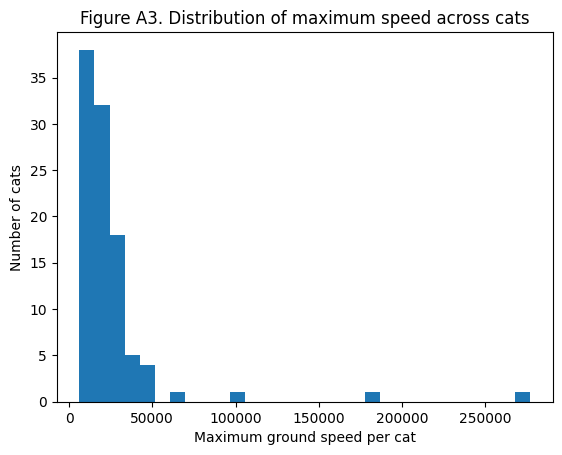

In [71]:
plt.figure()
plt.hist(cat_max_speed["max_speed"], bins=30)
plt.xlabel("Maximum ground speed per cat")
plt.ylabel("Number of cats")
plt.title("Figure A3. Distribution of maximum speed across cats")
plt.show()

The distribution of per cat maximum ground speed is highly right-skewed, with most cats having moderate maxima and a small number exhibiting extremely large maximum speeds. This suggests that rare high-speed episodes are concentrated in a few individuals and that max-based features may be sensitive to outliers. To better capture typical vs. extreme movement intensity, I therefore include both central-tendency measures and high-end summaries in later feature construction.

## 5. EDA Step 4: Mean vs Max Speed

In [ ]:
cat_speed_summary = (
    df.groupby(COL["cat_id"])[COL["speed"]]
      .agg(mean_speed="mean", max_speed="max", median_speed="median")
      .reset_index()
)

cat_speed_summary.head()

,tag_id,mean_speed,max_speed,median_speed
0,Abba-Tag,1603.951807,13968,864.0
1,Alfie-Tag,1931.679144,14652,1188.0
2,Amber-Tag,1967.614679,21888,1188.0
3,Ares,2285.825243,14328,1440.0
4,Athena,2134.188679,19728,1494.0


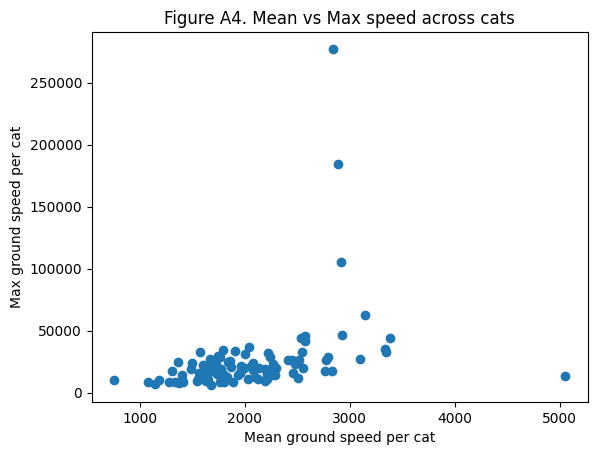

In [ ]:
plt.figure()
plt.scatter(cat_speed_summary["mean_speed"],
            cat_speed_summary["max_speed"])
plt.xlabel("Mean ground speed per cat")
plt.ylabel("Max ground speed per cat")
plt.title("Figure A4. Mean vs Max speed across cats")
plt.show()

The mean and max scatter shows a general positive relationship: cats with higher average speed tend to have higher maximum speed. However, several cats exhibit disproportionately large maxima relative to their mean, indicating brief extreme-speed bursts that are not reflected in average movement intensity. This reinforces the need for multiple speed summaries (mean/median alongside max and high-quantile features) when defining movement behavior profiles.

# Analysis & Experiments

## 6. Feature Construction & Scaling

In [61]:
display(features.head())
features.columns


,tag_id,n_obs,mean_speed,median_speed,max_speed,p75_speed,p95_speed,lat_span,lon_span,day_ratio
0,Abba-Tag,83,1603.951807,864.0,13968,1746.0,5763.6,0.003963,0.010782,0.361446
1,Alfie-Tag,187,1931.679144,1188.0,14652,2358.0,5752.8,0.004066,0.012550,0.459893
2,Amber-Tag,218,1967.614679,1188.0,21888,2475.0,6438.6,0.030289,0.040155,0.738532
3,Ares,103,2285.825243,1440.0,14328,2898.0,7891.2,0.002487,0.003378,0.213592
4,Athena,106,2134.188679,1494.0,19728,2862.0,5715.0,0.002319,0.003988,0.452830


Index(['tag_id', 'n_obs', 'mean_speed', 'median_speed', 'max_speed',
       'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio'],
      dtype='object')

In [62]:
feature_cols = [
    "n_obs",
    "mean_speed", "median_speed", "max_speed",
    "p75_speed", "p95_speed",
    "lat_span", "lon_span",
    "day_ratio"
]

X = features[feature_cols].copy()
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)

X shape: (101, 9)


## 7. Method 1: KMeans (K=2/3/4)

In [63]:
ks = [2, 3, 4]
rows = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "sizes": dict(pd.Series(labels).value_counts().sort_index())
    })

k_summary = pd.DataFrame(rows)
display(k_summary)

,k,inertia,silhouette,sizes
0,2,710.520302,0.291866,"{0: 65, 1: 36}"
1,3,520.885271,0.307024,"{0: 34, 1: 64, 2: 3}"
2,4,437.735607,0.285134,"{0: 60, 1: 3, 2: 37, 3: 1}"


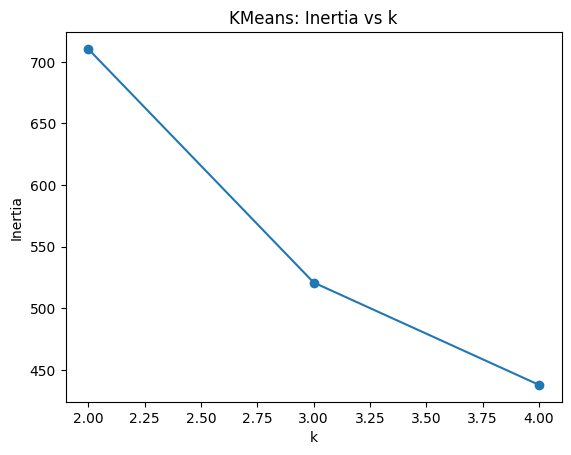

In [ ]:
plt.figure()
plt.plot(k_summary["k"], k_summary["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans: Inertia vs k")
plt.show()

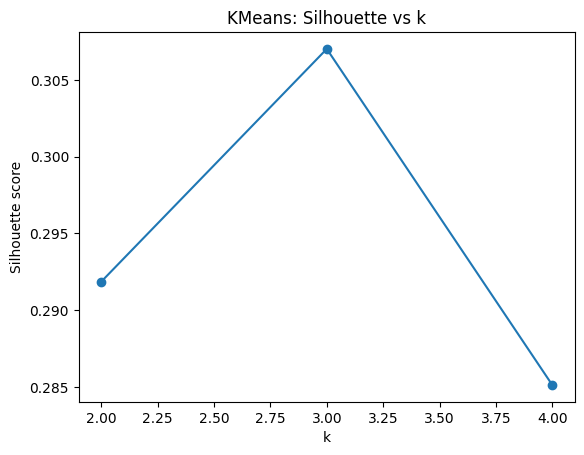

In [ ]:
plt.figure()
plt.plot(k_summary["k"], k_summary["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans: Silhouette vs k")
plt.show()

In [64]:
k_chosen = 3

km = KMeans(n_clusters=k_chosen, random_state=42, n_init=20)
labels_k = km.fit_predict(X_scaled)

features_k = features.loc[X.index].copy()
features_k["kmeans_cluster"] = labels_k

features_k["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,34
1,64
2,3


In [65]:
profile_cols = feature_cols

k_profile = (
    features_k
    .groupby("kmeans_cluster")[profile_cols]
    .median()
    .sort_index()
)

display(k_profile)

,n_obs,mean_speed,median_speed,max_speed,p75_speed,p95_speed,lat_span,lon_span,day_ratio
kmeans_cluster,,,,,,,,,
0,102.0,2528.062857,1476.0,23112.0,2871.0,7989.3,0.004381,0.006268,0.397807
1,171.5,1672.857786,1026.0,15858.0,2115.0,5364.0,0.004112,0.004833,0.420204
2,261.0,2541.568966,972.0,32472.0,2268.0,7452.0,0.369648,0.315137,0.623053


## 8. Method 2: Hierarchical

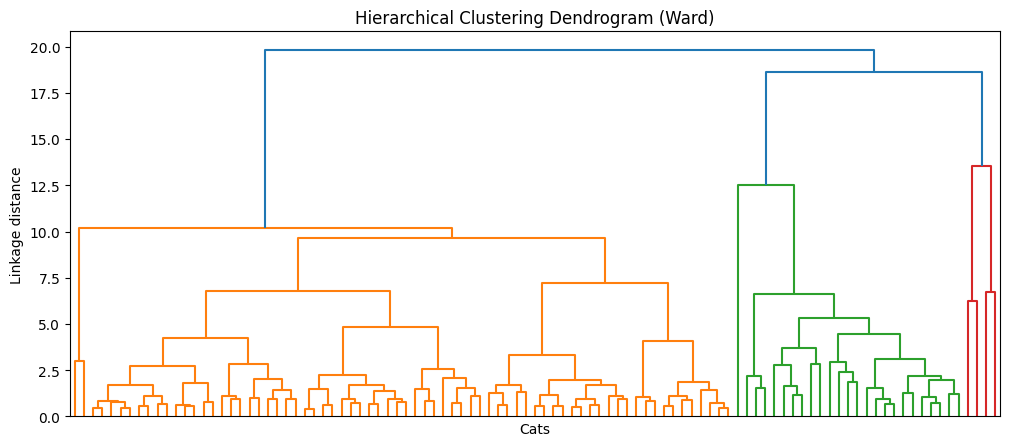

In [66]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Cats")
plt.ylabel("Linkage distance")
plt.show()

In [ ]:
rows = []
for n_clusters in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels = agg.fit_predict(X_scaled)
    rows.append({
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_scaled, labels),
        "sizes": dict(pd.Series(labels).value_counts().sort_index())
    })

h_summary = pd.DataFrame(rows)
display(h_summary)

,n_clusters,silhouette,sizes
0,2,0.344444,"{0: 29, 1: 72}"
1,3,0.327108,"{0: 4, 1: 72, 2: 25}"
2,4,0.337366,"{0: 25, 1: 72, 2: 2, 3: 2}"


In [67]:
h_chosen = 2

agg = AgglomerativeClustering(
    n_clusters=h_chosen,
    linkage="ward"
)

labels_h = agg.fit_predict(X_scaled)

features_h = features.loc[X.index].copy()
features_h["hier_cluster"] = labels_h

features_h["hier_cluster"].value_counts().sort_index()

,count
hier_cluster,
0,29
1,72


In [68]:
h_profile = (
    features_h
    .groupby("hier_cluster")[profile_cols]
    .median()
    .sort_index()
)

display(h_profile)

,n_obs,mean_speed,median_speed,max_speed,p75_speed,p95_speed,lat_span,lon_span,day_ratio
hier_cluster,,,,,,,,,
0,145.0,2576.623116,1422.0,26604.0,2862.0,8604.0,0.005882,0.011676,0.433036
1,157.5,1738.044791,1080.0,15480.0,2155.5,5414.4,0.004005,0.004572,0.420204


## 9. Summary of Clustering Experiments

Clustering was conducted on standardized cat-level movement features using K-Means and hierarchical clustering (Ward linkage) to explore overall behavioral structure. For KMeans, comparison across k =2,3,4 shows that k=3 achieves the highest silhouette score (≈ 0.307), indicating slightly improved separation relative to other choices. However, this solution includes a small cluster of three cats, suggesting limited but non-negligible heterogeneity rather than a fully stable partition. In contrast, hierarchical clustering yields its highest silhouette score at two clusters (≈ 0.344) and produces well-balanced group sizes (29 vs. 72 cats). Increasing the number of hierarchical clusters leads to very small groups, implying that further splits primarily isolate edge cases. Overall, both methods indicate the presence of a small number of broad movement profiles, supporting the use of clustering as a descriptive summary tool rather than evidence of sharply distinct behavioral types.